# Power analysis attack on ASCON

In [1]:
import sys
import os
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from tqdm import tqdm
import time

## Project paths
This block robustly detects the project root (`DOJO_ROOT`) starting from either the script location (`__file__`) or the current working directory (for notebooks). From there it defines all relevant subdirectories (ASCON sources, SCA scripts, X-HEEP, traces, plots, cache), ensures output folders exist, and adds the local source paths to `sys.path` .

In [2]:
def find_project_root(start: Path, markers=("fusesoc.conf", ".dojo_root")) -> Path:
    current = start
    while current != current.parent:
        if any((current / m).exists() for m in markers):
            return current
        current = current.parent

    raise RuntimeError(
        f"Could not find project root (looked for markers: {markers}). "
        "Please ensure you are inside the Side-Channel-Dojo repository."
    )


# In a script, __file__ exists; in a notebook, it does not.
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    # Notebook / interactive: use the current working directory instead
    SCRIPT_DIR = Path.cwd()

DOJO_ROOT = find_project_root(SCRIPT_DIR)

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
XHEEP_DIR    = DOJO_ROOT / "sw" / "x-heep"
ASCON_PY_DIR = DOJO_ROOT / "sw" / "ciphers" / "ASCON_init_python"
SCA_DIR      = DOJO_ROOT / "sw" / "sca_scripts"
HW_DIR       = DOJO_ROOT / "hw"

# Traces and plots PATH for ASCON SW
TRACESET_DIR = DOJO_ROOT / "sw" / "traceset" / "ASCON" / "sw"
BASE_PLOT_DIR = DOJO_ROOT / "sw" / "sca_scripts" / "ASCON" / "sw" / "plot"

TRACESET_DIR.mkdir(parents=True, exist_ok=True)
BASE_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Make local modules importable without fragile ../ relative paths
sys.path.insert(0, str(ASCON_PY_DIR))
sys.path.insert(0, str(SCA_DIR))
sys.path.insert(0, str(XHEEP_DIR))

In [ ]:
import readFirmware
from pico_api import PS5000aWrapper
import chipwhisperer as cw
from analyzer.utils.sca_plots import sca_plot
from analyzer.attack.ascon.xheep_ascon_cpa.ascon_first_round import ascon_first_round
# from analyzer.attack.ascon.xheep_ascon_cpa.ascon_leakage_model_64 import ascon_leakage_model
from analyzer.attack.ascon.xheep_ascon_cpa.ascon_cpa import ascon_cpa


## Configuration

In [4]:
# Available S-box implementations
AVAILABLE_SBOXES = [  
    "lut_ascon",   
    "lut_bilgin",  
    "lut_allouzi", 
    "lut_lu_4",
    "lut_lu_5",
    "lut_lu_6",
    "lut_lu_7",
]

# Select which ASCON S-box / sub-layer implementation to test
sbox_type = "lut_lu_5"  # "hw", "lut_ascon", "lut_bilgin", ...

# Flow flags
n_trc                  = 10000  # Number of traces to capture
save_traces            = True   # Store traces into a h5 file (.h5)
traces_overlapped_plot = True   # Plot overlapped power traces
save_plot              = True   # Save overlapped plot to disk

bitstream_path = (
    HW_DIR
    / "fpga"
    / "bitstream"
    / "xheep"
    / "cw305_top.bit"
)

bitstream = str(bitstream_path)

VERILOG_DEFINES = (
    HW_DIR
    / "vendor"
    / "cw305-heep"
    / "hw"
    / "fpga"
    / "cw305_aes_defines.v"
)

# Precompiled ASCON firmware for the CW305 board
FIRMWARE_FILE = (
    DOJO_ROOT
    / "sw"
    / "x-heep"
    / "ASCON_firmware"
    / f"ascon_opt32_{sbox_type}_150k.hex"
    #/ f"ascon_opt32_{sbox_type}_{n_trc // 1000}k.hex"
)
# To run another firmware compiled with the xheep toolchain, uncomment:
# FIRMWARE_FILE = HW_DIR / "vendor" / "cw305-heep" / "sw" / "build" / "main.hex"

# Traces file path (board-captured traces)
TRACESET_FILE = TRACESET_DIR / f"ascon_opt32_{sbox_type}_{n_trc // 1000}k_tmp.h5"

# Directory for plots for this sub-layer
PLOT_DIR = BASE_PLOT_DIR / f"{sbox_type}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Helper for pretty yes/no printing
# ---------------------------------------------------------------------------

def _yn(flag: bool) -> str:
    return "yes" if flag else "no"

# ---------------------------------------------------------------------------
# Configuration printout
# ---------------------------------------------------------------------------
print("\n================= CAPTURE OF ASCON HW CONFIGURATION =================")
print(f"DOJO_ROOT           : {DOJO_ROOT}")
print()
print("Target")
print(f"  S-box type        : {sbox_type}")
print()
print("Paths")
print(f"  Bitstream         : {bitstream_path}")
print(f"  Verilog defines   : {VERILOG_DEFINES}")
print(f"  Firmware          : {FIRMWARE_FILE}")
print(f"  HW traces file    : {TRACESET_FILE}")
print(f"  SCA traces dir    : {TRACESET_DIR}")
print(f"  Plot dir          : {PLOT_DIR}")
print("Online phase")
print(f"  Number of traces  : {n_trc}")
print(f"  Save traces       : {_yn(save_traces)}")
print(f"  Overlapped plot   : {_yn(traces_overlapped_plot)}")
print(f"  Save plot         : {_yn(save_plot)}")
print("==========================================================\n")


================= CAPTURE OF ASCON HW CONFIGURATION =================
DOJO_ROOT           : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo

Target
  S-box type        : lut_lu_5

Paths
  Bitstream         : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/hw/fpga/bitstream/xheep/cw305_top.bit
  Verilog defines   : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/hw/vendor/cw305-heep/hw/fpga/cw305_aes_defines.v
  Firmware          : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/x-heep/ASCON_firmware/ascon_opt32_lut_lu_5_150k.hex
  HW traces file    : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/sw/ascon_opt32_lut_lu_5_10k_tmp.h5
  SCA traces dir    : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/sw
  Plot dir          : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/sca_scripts/ASCON/sw/plot/lut_lu_5
Online phase
  Number of traces  : 10000
  Save traces       : yes
  Overlapped plot   : yes
  Save plot         : yes



## Board preparation

In [5]:
def prepare_board(firmware: str):
    """
    Prepare the CW305 + X-HEEP board for the attack:
      1. Initialize the PicoScope.
      2. Initialize CW305 with the given bitstream and Verilog defines.
      3. Configure PLL and clock settings.
      4. Load the X-HEEP firmware into the microcontroller.

    Returns:
        (ps, cw305) handles for scope and board.
    """
    try:
        # 1) Initialize PicoScope
        ps = PS5000aWrapper()
        ps.get_unitInfo()
        # The scope is triggered before the registers update, and it is set for only 34 clock cycles.
        #ps.scope_setup(obs_time=3.5E-6, nSamples=350) # ~3.5 us, 350 samples
        #ps.scope_setup(obs_time=6E-6, nSamples=600) # ~6 us, 600 samples
        ps.scope_setup(obs_time=9E-6, nSamples=900) # ~9 us, 900 samples


        # 2) Initialize CW305 with required parameters
        cw305 = cw.target(
            None,
            cw.targets.CW305,
            bsfile=bitstream,
            force=True,
            slurp=True,
            defines_files=[VERILOG_DEFINES],
        )

        cw305.vccint_set(1.0)
        cw305.pll.pll_enable_set(True)        # enable PLL chip
        cw305.pll.pll_outenable_set(False, 0) # disable PLL 0
        cw305.pll.pll_outenable_set(True, 1)  # enable PLL 1
        cw305.pll.pll_outenable_set(False, 2) # disable PLL 2
        cw305.pll.pll_outfreq_set(10e6, 1)    # PLL1 frequency set to 10 MHz

        # Disable USB clock (optional, reduces noise in the power traces)
        cw305.clkusbautooff = True
        # Idle time between captures
        cw305.clksleeptime = 1

        # 3) Set the clock source via FPGA register
        cw305.fpga_write(cw305.REG_CLKSETTINGS, data=bytearray([0x01]))

        # 4) Load firmware into X-HEEP
        readFirmware.readFirmware(cw305, firmware)

        return ps, cw305

    except ModuleNotFoundError as e:
        print(e)


## Online phase : ASCON power traces capture

In [6]:
# Default sampling interval is 8 ns
sampling_interval = 8e-9

# ASCON key, nonce and IV (strings, big-endian hex)
key_hex   = "000102030405060708090A0B0C0D0E0F"
nonce_hex = "000102030405060708090A0B0C0D0E0F"
iv_hex    = "00001000808C0001"  # From ASCON-128a parameters

# Nonce and key are reversed by groups of 2 char (to be compliant with C endianness)
# which are converted to integers

# Reverse key by bytes (2 hex chars per byte) to match C endianness
key_bytes = [key_hex[i:i+2] for i in range(0, len(key_hex), 2)]
key_reversed_hex = "".join(key_bytes[::-1])
key = int(key_reversed_hex, 16)

# Pretty print key as byte list
formatted_key = [key_reversed_hex[i:i+2] for i in range(0, len(key_reversed_hex), 2)]
print(f"[ONLINE] Fixed key used for acquisition (hex, LSB first): {formatted_key}")

# Reverse nonce by bytes (2 hex chars per byte)
nonce_bytes = [nonce_hex[i:i+2] for i in range(0, len(nonce_hex), 2)]
nonce_reversed_hex = "".join(nonce_bytes[::-1])
nonce = int(nonce_reversed_hex, 16)

iv_int = int(iv_hex, 16)

print(f"[ONLINE] Trace acquisition enabled. Target traces: {n_trc}")
print(f"[ONLINE] Using bitstream      : {bitstream_path}")
print(f"[ONLINE] Firmware             : {FIRMWARE_FILE}")
print(f"[ONLINE] HDF5 traceset target : {TRACESET_FILE}")

# -----------------------------------------------------------------------
# Prepare board (PicoScope + CW305)
# -----------------------------------------------------------------------
try:
    ps, cw305 = prepare_board(FIRMWARE_FILE)
    print("\n[ONLINE] Board initialized successfully.")
    print("[ONLINE] Picoscope settings:")
    print(ps.get_scopeSettings())
    sampling_interval = ps.get_samplingInterval()
    print(f"[ONLINE] Sampling Interval   : {sampling_interval} s\n")
except Exception as e:
    print(f"[ERROR] Failed to prepare board (PicoScope + CW305): {e}")
    raise

# -----------------------------------------------------------------------
# Trace acquisition 
# -----------------------------------------------------------------------
traces = None
nonces = None

try:
    # Initialize storage arrays after we know the number of samples
    n_samples = ps.get_nSamples()
    traces = np.empty((n_trc, n_samples), dtype=float)
    nonces = np.empty((n_trc, 2), dtype=np.uint64)

    print("[ONLINE] Starting trace capture...")
    for i in tqdm(range(n_trc), desc="Capturing traces"):
        # Start acquisition on PicoScope
        ps.runBlock()
        time.sleep(0.05)

        # Trigger program execution and acquisition via status register
        cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x08]))
        ps.waitReady()

        # Retrieve captured power trace
        data = ps.getDataV()
        trace = np.array(data, dtype=float)

        # Store trace
        traces[i] = trace

        # Store nonce halves (little-endian 2×64-bit representation)
        nonces[i, 0] = (nonce >> 64) & 0xFFFFFFFFFFFFFFFF  # least significant 64 bits
        nonces[i, 1] = nonce & 0xFFFFFFFFFFFFFFFF          # most significant 64 bits

        # Update nonce for next iteration using 2 state registers
        S = ascon_first_round(key, nonce, sbox_type)
        nonce = (S[3] << 64) | S[4]

        time.sleep(1e-3)  # 1 ms

        # Reset the status register  to reload the program execution and the scope acquisition
        cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x00]))

    # -------------------------------------------------------------------
    # Save traces to HDF5
    # -------------------------------------------------------------------
    if save_traces:
        print("[ONLINE] Saving traces to HDF5...")
        with h5py.File(TRACESET_FILE, "w") as f_write_traces:
            f_write_traces.create_dataset("nonces", data=nonces)
            f_write_traces.create_dataset("traces", data=traces)
            # Optionally store some metadata as attributes
            f_write_traces.attrs["sampling_interval"] = sampling_interval
            f_write_traces.attrs["n_traces"] = n_trc
            f_write_traces.attrs["n_samples"] = n_samples
            f_write_traces.attrs["key_hex_lsb_first"] = key_reversed_hex
            f_write_traces.attrs["nonce_initial_hex_lsb_first"] = nonce_reversed_hex
            f_write_traces.attrs["iv_hex"] = iv_hex

        print(f"[ONLINE] Capture completed. Traces saved to: {TRACESET_FILE}")
    else:
        print("[ONLINE] Capture completed. Traces were not saved (save_traces = False).")

except Exception as e:
    print(f"[ERROR] Capture aborted due to error: {e}")
    raise
finally:
    # Disconnect CW305 and PicoScope (online phase done)
    print("[ONLINE] Shutting down instruments...")
    try:
        cw305.dis()
    except Exception:
        pass
    try:
        ps.dis()
    except Exception:
        pass


[ONLINE] Fixed key used for acquisition (hex, LSB first): ['0F', '0E', '0D', '0C', '0B', '0A', '09', '08', '07', '06', '05', '04', '03', '02', '01', '00']
[ONLINE] Trace acquisition enabled. Target traces: 10000
[ONLINE] Using bitstream      : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/hw/fpga/bitstream/xheep/cw305_top.bit
[ONLINE] Firmware             : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/x-heep/ASCON_firmware/ascon_opt32_lut_lu_5_150k.hex
[ONLINE] HDF5 traceset target : /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/sw/ascon_opt32_lut_lu_5_10k_tmp.h5
Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.10.5074
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : 11768/0019
CalDate                       : 24Feb25
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFir

Capturing traces: 100%|██████████| 10000/10000 [12:00<00:00, 13.88it/s]


[ONLINE] Saving traces to HDF5...
[ONLINE] Capture completed. Traces saved to: /home/mattia-mirigaldi/Desktop/Side-Channel-Dojo/sw/traceset/ASCON/sw/ascon_opt32_lut_lu_5_10k_tmp.h5
[ONLINE] Shutting down instruments...


### Plotting power traces captured (40 samples overlapped)
Useful for debug purpose and to see if the power traces are aligned.

Generating power traces overlapped plot...


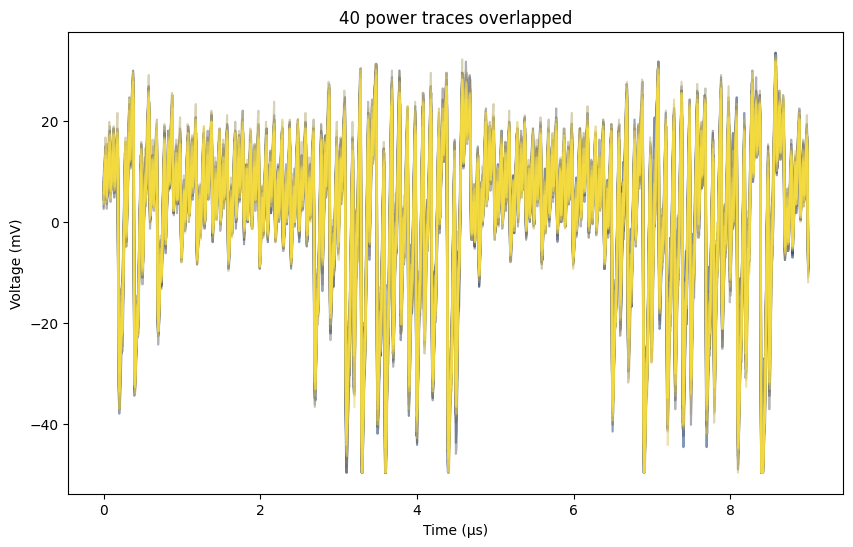

In [8]:
if traces_overlapped_plot:
    # Re-open the project for offline analysis
    try:
        with h5py.File(TRACESET_FILE, 'r') as f_read_traces:
            # Read the first 40 traces and nonces. It is better to use the slicing
            # operator even to load the whole dataset, since with the h5 format
            # data is read from the disk each time. The slicing operator forces the data
            # to be loaded into the RAM.
            traces = f_read_traces['traces'][:40]
        print("Generating power traces overlapped plot...")
        sca_plt = sca_plot()
        power_plt = sca_plt.power_traces_overlapped(
            list(traces), 
            sampling_interval
        )

        out_file = (
            PLOT_DIR / f"ASCON_power_traces_overlapped_{sbox_type}.pdf"
        )
        if (save_plot):
            power_plt.savefig(out_file)
        power_plt.show()
    except FileNotFoundError:
        print(f"ERROR: Traces file {TRACESET_FILE} not found. Please run the trace acquisition phase first.")